<a href="https://colab.research.google.com/github/Arooba93/MyProjects/blob/main/Performance_report_on_exisiting_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extract Dataset & Setup Environment

In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive only if it's not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted.')

# Define paths
zip_path = '/content/drive/MyDrive/archive.zip'
extract_dir = '/content/chest_xray_data'

# Unzip the data
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Data extracted to {extract_dir}")
# Update these paths based on the exact folder structure inside your zip file
train_dir = os.path.join(extract_dir, 'chest_xray/train')
test_dir = os.path.join(extract_dir, 'chest_xray/test')

Google Drive already mounted.
Data extracted to /content/chest_xray_data


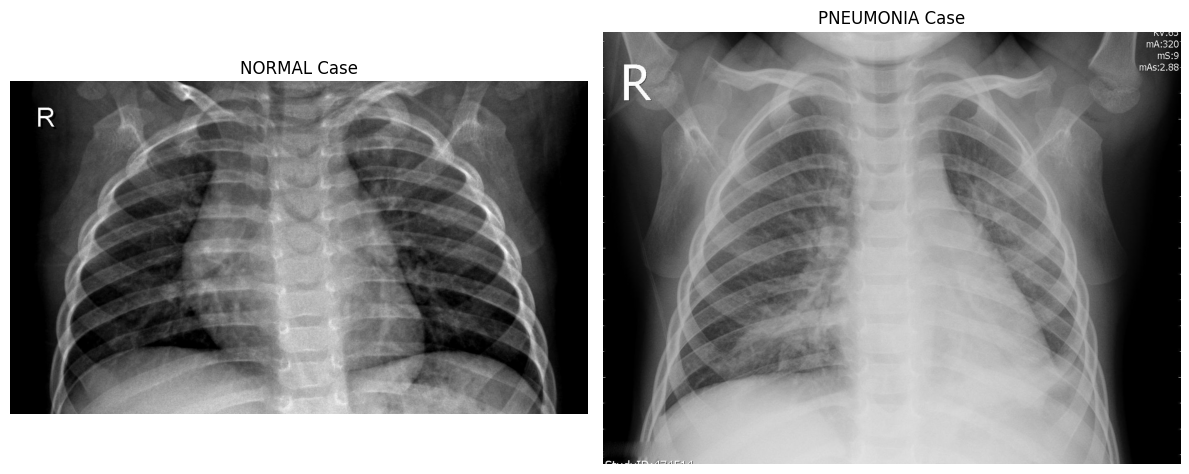

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Assuming test_dir and class_dirs are already defined from previous cells
# test_dir = '/content/chest_xray_data/chest_xray/test'
# class_dirs = ['NORMAL', 'PNEUMONIA']

image_samples = {}

# Find a sample image for 'NORMAL' class
normal_dir = os.path.join(test_dir, 'NORMAL')
if os.path.exists(normal_dir):
    normal_images = [f for f in os.listdir(normal_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    if normal_images:
        image_samples['NORMAL'] = os.path.join(normal_dir, normal_images[0])

# Find a sample image for 'PNEUMONIA' class
pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')
if os.path.exists(pneumonia_dir):
    pneumonia_images = [f for f in os.listdir(pneumonia_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    if pneumonia_images:
        image_samples['PNEUMONIA'] = os.path.join(pneumonia_dir, pneumonia_images[0])

# Display the images if found
if image_samples:
    fig, axes = plt.subplots(1, len(image_samples), figsize=(12, 6))
    if len(image_samples) == 1:
        axes = [axes] # Make it an iterable if only one image

    for i, (label, img_path) in enumerate(image_samples.items()):
        img = Image.open(img_path)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'{label} Case')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Could not find sample images for both NORMAL and PNEUMONIA classes.")
    print("Please ensure the data is correctly extracted and the paths are valid.")

Load the necessary modules for deep learning, metric calculations, and visualization.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Using device: cuda


In [ ]:
# Traverse the extracted folder to find all images
# Adjust the extension (.jpeg, .png, .jpg) based on your specific archive contents
import glob
import pandas as pd

# Corrected: Using 'extract_dir' which was defined earlier
all_images = glob.glob(f'{extract_dir}/**/*.jpeg', recursive=True)

# Extract labels from folder names (assuming folders are named 'NORMAL' and 'PNEUMONIA')
labels = ['PNEUMONIA' if 'PNEUMONIA' in path.upper() else 'NORMAL' for path in all_images]

# Create a master dataframe
df = pd.DataFrame({'filename': all_images, 'class': labels})
print(f"Total images found: {len(df)}")
print(df['class'].value_counts())

Total images found: 11712
class
PNEUMONIA    8546
NORMAL       3166
Name: count, dtype: int64


In [ ]:
def build_resnet50_model():
    # Load Pre-trained ResNet50
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))

    # Fine-tuning: Freeze all but the last 10 layers
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.5), # Optimization: Dropout to prevent overfitting
        Dense(1, activation='sigmoid') # Binary classification
    ])

    # Optimization: Adam optimizer with a low learning rate for fine-tuning
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

```markdown
## Optimization Options for Model Training

To further improve the model's performance, prevent overfitting, and potentially speed up training, here are several optimization options you could consider:

1.  **Learning Rate Scheduling:** Instead of a fixed learning rate, you can adjust it during training. Common schedulers include:
    *   **StepLR:** Decreases the learning rate by a factor every few epochs.
    *   **CosineAnnealingLR:** Decays the learning rate following a cosine curve.
    *   **ReduceLROnPlateau:** Reduces the learning rate when a metric (e.g., validation loss) stops improving.

2.  **Regularization Techniques:** These help prevent overfitting, especially when working with smaller datasets or complex models:
    *   **Dropout:** Randomly sets a fraction of input units to 0 at each update during training time, which helps prevent co-adaptation of neurons.
    *   **Weight Decay (L2 Regularization):** Adds a penalty to the loss function that is proportional to the square of the magnitude of weights, encouraging smaller weights.

3.  **Advanced Data Augmentation:** While basic augmentation (horizontal flip, rotation) was applied, more advanced techniques can further boost robustness:
    *   **Mixup/Cutmix:** Combines multiple images and their labels to create new training samples.
    *   **AutoAugment/RandAugment:** Automatically learns or randomly samples optimal augmentation policies.

4.  **Early Stopping:** Monitor a validation metric (e.g., validation loss or accuracy) and stop training when it stops improving for a certain number of epochs (patience). This prevents the model from overfitting to the training data and saves computational resources.

5.  **Different Optimizers:** While Adam is a good general-purpose optimizer, others like `SGD` with `momentum` or `AdamW` (Adam with decoupled weight decay) might yield better results for specific tasks or architectures.

6.  **Transfer Learning Strategies:** If not already done, consider freezing earlier layers of the pre-trained ResNet and only training the later layers and the new classification head. Then, gradually unfreeze more layers and fine-tune with a smaller learning rate.

Which of these would you like to explore or implement next?
```

Cross-Validation Pipeline & Training
This executes the K-Fold process. Optimization features included:

Data Augmentation: Flips, zooms, and shifts to prevent overfitting.

Early Stopping: Halts training if validation loss stops improving.

ReduceLROnPlateau: Drops the learning rate dynamically when learning stagnates.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tqdm.keras import TqdmCallback

# Set your hyperparameters here
EPOCHS = 10
FOLDS = 3
SEED = 42
BATCH_SIZE = 64
IMG_SIZE = (128, 128) # Decreased image size to save time

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

# Dictionaries to store metrics and paths for each fold
fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
saved_model_paths = []
all_y_true = []
all_y_pred_probs = []

# Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10, # Optimization: Data Augmentation
    zoom_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

for fold, (train_idx, val_idx) in enumerate(skf.split(df['filename'], df['class'])):
    print(f"\n--- Starting Fold {fold + 1}/{FOLDS} ---")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_generator = train_datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='class', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
    )

    val_generator = val_datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='class', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
    )

    model = build_resnet50_model()
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    model_path = f'/content/drive/MyDrive/resnet50_fold_{fold+1}.keras'
    saved_model_paths.append(model_path)

    # Optimization: Callbacks
    callbacks = [
        EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'), # Reduced patience
        ReduceLROnPlateau(factor=0.2, patience=2, min_lr=1e-6, monitor='val_loss'), # Reduced patience
        ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss'),
        TqdmCallback(verbose=1) # Progress bar
    ]

    # Train
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=0 # Tqdm handles the progress bar
    )

    # Evaluate on validation fold
    y_true = val_generator.classes
    y_pred_probs = model.predict(val_generator).flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)

    # Store aggregate data for final visualizations
    all_y_true.extend(y_true)
    all_y_pred_probs.extend(y_pred_probs)

    # Calculate Metrics
    fold_metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    fold_metrics['precision'].append(precision_score(y_true, y_pred))
    fold_metrics['recall'].append(recall_score(y_true, y_pred))
    fold_metrics['f1'].append(f1_score(y_true, y_pred))
    fold_metrics['auc'].append(roc_auc_score(y_true, y_pred_probs))

print("\nSaved Model Paths:")
for path in saved_model_paths:
    print(path)


--- Starting Fold 1/3 ---
Found 7808 validated image filenames belonging to 2 classes.
Found 3904 validated image filenames belonging to 2 classes.


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

61/61 ━━━━━━━━━━━━━━━━━━━━ 41s 609ms/step

--- Starting Fold 2/3 ---
Found 7808 validated image filenames belonging to 2 classes.
Found 3904 validated image filenames belonging to 2 classes.


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 567ms/step

--- Starting Fold 3/3 ---
Found 7808 validated image filenames belonging to 2 classes.
Found 3904 validated image filenames belonging to 2 classes.


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

61/61 ━━━━━━━━━━━━━━━━━━━━ 42s 621ms/step

Saved Model Paths:
/content/drive/MyDrive/resnet50_fold_1.keras
/content/drive/MyDrive/resnet50_fold_2.keras
/content/drive/MyDrive/resnet50_fold_3.keras


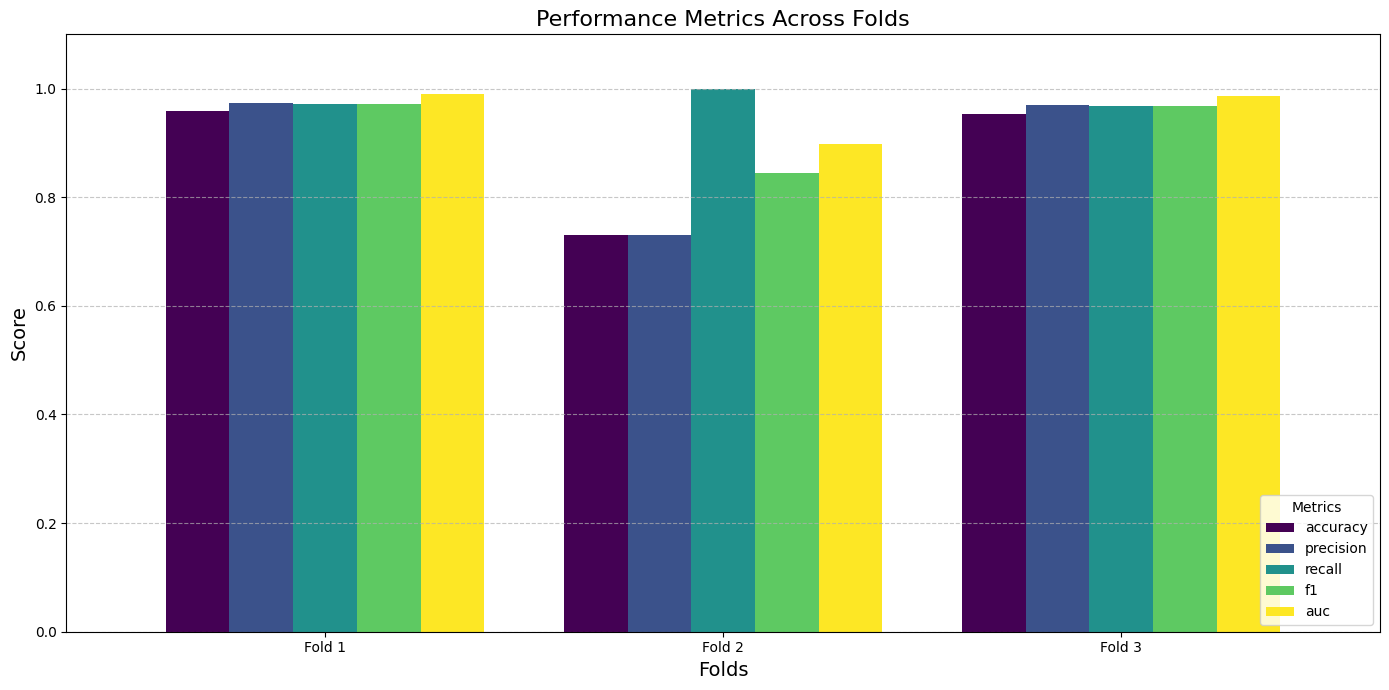


--- Cross-Validation Summary ---


,Average,Std Dev
accuracy,0.880977,0.130976
precision,0.890583,0.139287
recall,0.979639,0.017689
f1,0.928074,0.073026
auc,0.958060,0.052043


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert the metrics dictionary to a pandas DataFrame
metrics_df = pd.DataFrame(fold_metrics)

# Only plot if metrics have been collected (i.e., after training completes)
if not metrics_df.empty:
    metrics_df.index = [f'Fold {i+1}' for i in range(len(metrics_df))]

    # Plot a grouped bar chart
    ax = metrics_df.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='viridis')
    plt.title('Performance Metrics Across Folds', fontsize=16)
    plt.ylabel('Score', fontsize=14)
    plt.xlabel('Folds', fontsize=14)
    plt.ylim(0, 1.1)
    plt.xticks(rotation=0)
    plt.legend(title='Metrics', loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Display average and standard deviation
    print("\n--- Cross-Validation Summary ---")
    summary_df = pd.DataFrame({
        'Average': metrics_df.mean(),
        'Std Dev': metrics_df.std()
    })
    display(summary_df)
else:
    print("No metrics to display yet. Please wait for the cross-validation training to finish.")

In [ ]:
print("\n--- 3-Fold Cross Validation Results ---")
for metric, values in fold_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"{metric.capitalize()}: {mean_val:.4f} ± {std_val:.4f}")


--- 3-Fold Cross Validation Results ---
Accuracy: 0.8810 ± 0.1069
Precision: 0.8906 ± 0.1137
Recall: 0.9796 ± 0.0144
F1: 0.9281 ± 0.0596
Auc: 0.9581 ± 0.0425


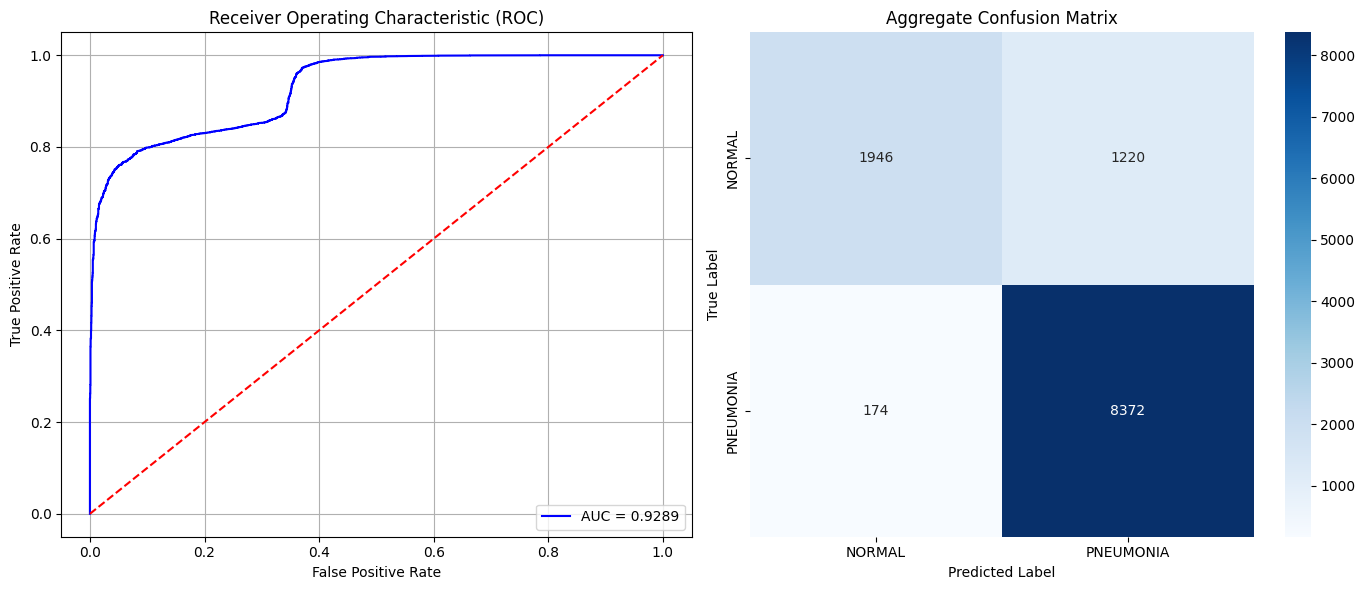

In [ ]:
# Convert aggregates to arrays
true_labels = np.array(all_y_true)
pred_probs = np.array(all_y_pred_probs)
pred_labels = (pred_probs > 0.5).astype(int)

plt.figure(figsize=(14, 6))

# 1. ROC Curve
plt.subplot(1, 2, 1)
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
auc_score = roc_auc_score(true_labels, pred_probs)
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.title('Aggregate Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### Implementing Cosine Annealing in Keras
To use a Cosine Annealing schedule in Keras pipeline, we define a scheduling function and pass it to the `LearningRateScheduler` callback. then just replace `ReduceLROnPlateau` with this new callback in training loop.

In [ ]:
import math
from tensorflow.keras.callbacks import LearningRateScheduler

# 1. Define the Cosine Annealing schedule function
def cosine_annealing_schedule(epoch, current_lr):
    initial_lr = 1e-4  # Your initial learning rate
    total_epochs = EPOCHS
    # Calculate the new learning rate using the cosine formula
    lr = initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))
    return lr

# 2. Create the callback
cosine_scheduler = LearningRateScheduler(cosine_annealing_schedule, verbose=1)

print("Cosine Annealing Scheduler defined!")

Cosine Annealing Scheduler defined!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tqdm.keras import TqdmCallback

# Set your hyperparameters here
EPOCHS = 10
FOLDS = 3
SEED = 42
BATCH_SIZE = 64
IMG_SIZE = (128, 128) # Decreased image size to save time

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

# Dictionaries to store metrics and paths for each fold
fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
saved_model_paths = []
all_y_true = []
all_y_pred_probs = []
all_histories = [] # Added list to track histories for plotting

# Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10, # Optimization: Data Augmentation
    zoom_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

for fold, (train_idx, val_idx) in enumerate(skf.split(df['filename'], df['class'])):
    print(f"\n--- Starting Fold {fold + 1}/{FOLDS} ---")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_generator = train_datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='class', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
    )

    val_generator = val_datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='class', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
    )

    model = build_resnet50_model()
    model_path = f'/content/drive/MyDrive/resnet50_fold_{fold+1}.keras'
    saved_model_paths.append(model_path)

    # Optimization: Callbacks
    callbacks = [
        EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'), # Reduced patience
        cosine_scheduler, # Replaced ReduceLROnPlateau
        ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss'),
        TqdmCallback(verbose=1) # Progress bar
    ]

    # Train
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=0 # Tqdm handles the progress bar
    )

    # Save history for visualization
    all_histories.append(history.history)

    # Evaluate on validation fold
    y_true = val_generator.classes
    y_pred_probs = model.predict(val_generator).flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)

    # Store aggregate data for final visualizations
    all_y_true.extend(y_true)
    all_y_pred_probs.extend(y_pred_probs)

    # Calculate Metrics
    fold_metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    fold_metrics['precision'].append(precision_score(y_true, y_pred))
    fold_metrics['recall'].append(recall_score(y_true, y_pred))
    fold_metrics['f1'].append(f1_score(y_true, y_pred))
    fold_metrics['auc'].append(roc_auc_score(y_true, y_pred_probs))

print("\nSaved Model Paths:")
for path in saved_model_paths:
    print(path)



--- Starting Fold 1/3 ---
Found 7808 validated image filenames belonging to 2 classes.
Found 3904 validated image filenames belonging to 2 classes.


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.

Epoch 2: LearningRateScheduler setting learning rate to 9.755282581475769e-05.

Epoch 3: LearningRateScheduler setting learning rate to 9.045084971874738e-05.

Epoch 4: LearningRateScheduler setting learning rate to 7.938926261462366e-05.

Epoch 5: LearningRateScheduler setting learning rate to 6.545084971874738e-05.

Epoch 6: LearningRateScheduler setting learning rate to 5e-05.

Epoch 7: LearningRateScheduler setting learning rate to 3.4549150281252636e-05.

Epoch 8: LearningRateScheduler setting learning rate to 2.061073738537635e-05.

Epoch 9: LearningRateScheduler setting learning rate to 9.549150281252633e-06.

Epoch 10: LearningRateScheduler setting learning rate to 2.4471741852423237e-06.
61/61 ━━━━━━━━━━━━━━━━━━━━ 41s 602ms/step

--- Starting Fold 2/3 ---
Found 7808 validated image filenames belonging to 2 classes.
Found 3904 validated image filenames belonging to 2 classes.


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.

Epoch 2: LearningRateScheduler setting learning rate to 9.755282581475769e-05.

Epoch 3: LearningRateScheduler setting learning rate to 9.045084971874738e-05.

Epoch 4: LearningRateScheduler setting learning rate to 7.938926261462366e-05.
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 589ms/step

--- Starting Fold 3/3 ---
Found 7808 validated image filenames belonging to 2 classes.
Found 3904 validated image filenames belonging to 2 classes.


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.

Epoch 2: LearningRateScheduler setting learning rate to 9.755282581475769e-05.

Epoch 3: LearningRateScheduler setting learning rate to 9.045084971874738e-05.

Epoch 4: LearningRateScheduler setting learning rate to 7.938926261462366e-05.

Epoch 5: LearningRateScheduler setting learning rate to 6.545084971874738e-05.

Epoch 6: LearningRateScheduler setting learning rate to 5e-05.

Epoch 7: LearningRateScheduler setting learning rate to 3.4549150281252636e-05.

Epoch 8: LearningRateScheduler setting learning rate to 2.061073738537635e-05.

Epoch 9: LearningRateScheduler setting learning rate to 9.549150281252633e-06.

Epoch 10: LearningRateScheduler setting learning rate to 2.4471741852423237e-06.
61/61 ━━━━━━━━━━━━━━━━━━━━ 42s 624ms/step

Saved Model Paths:
/content/drive/MyDrive/resnet50_fold_1.keras
/content/drive/MyDrive/resnet50_fold_2.keras
/content/drive/MyDrive/resnet50_fold_3.keras


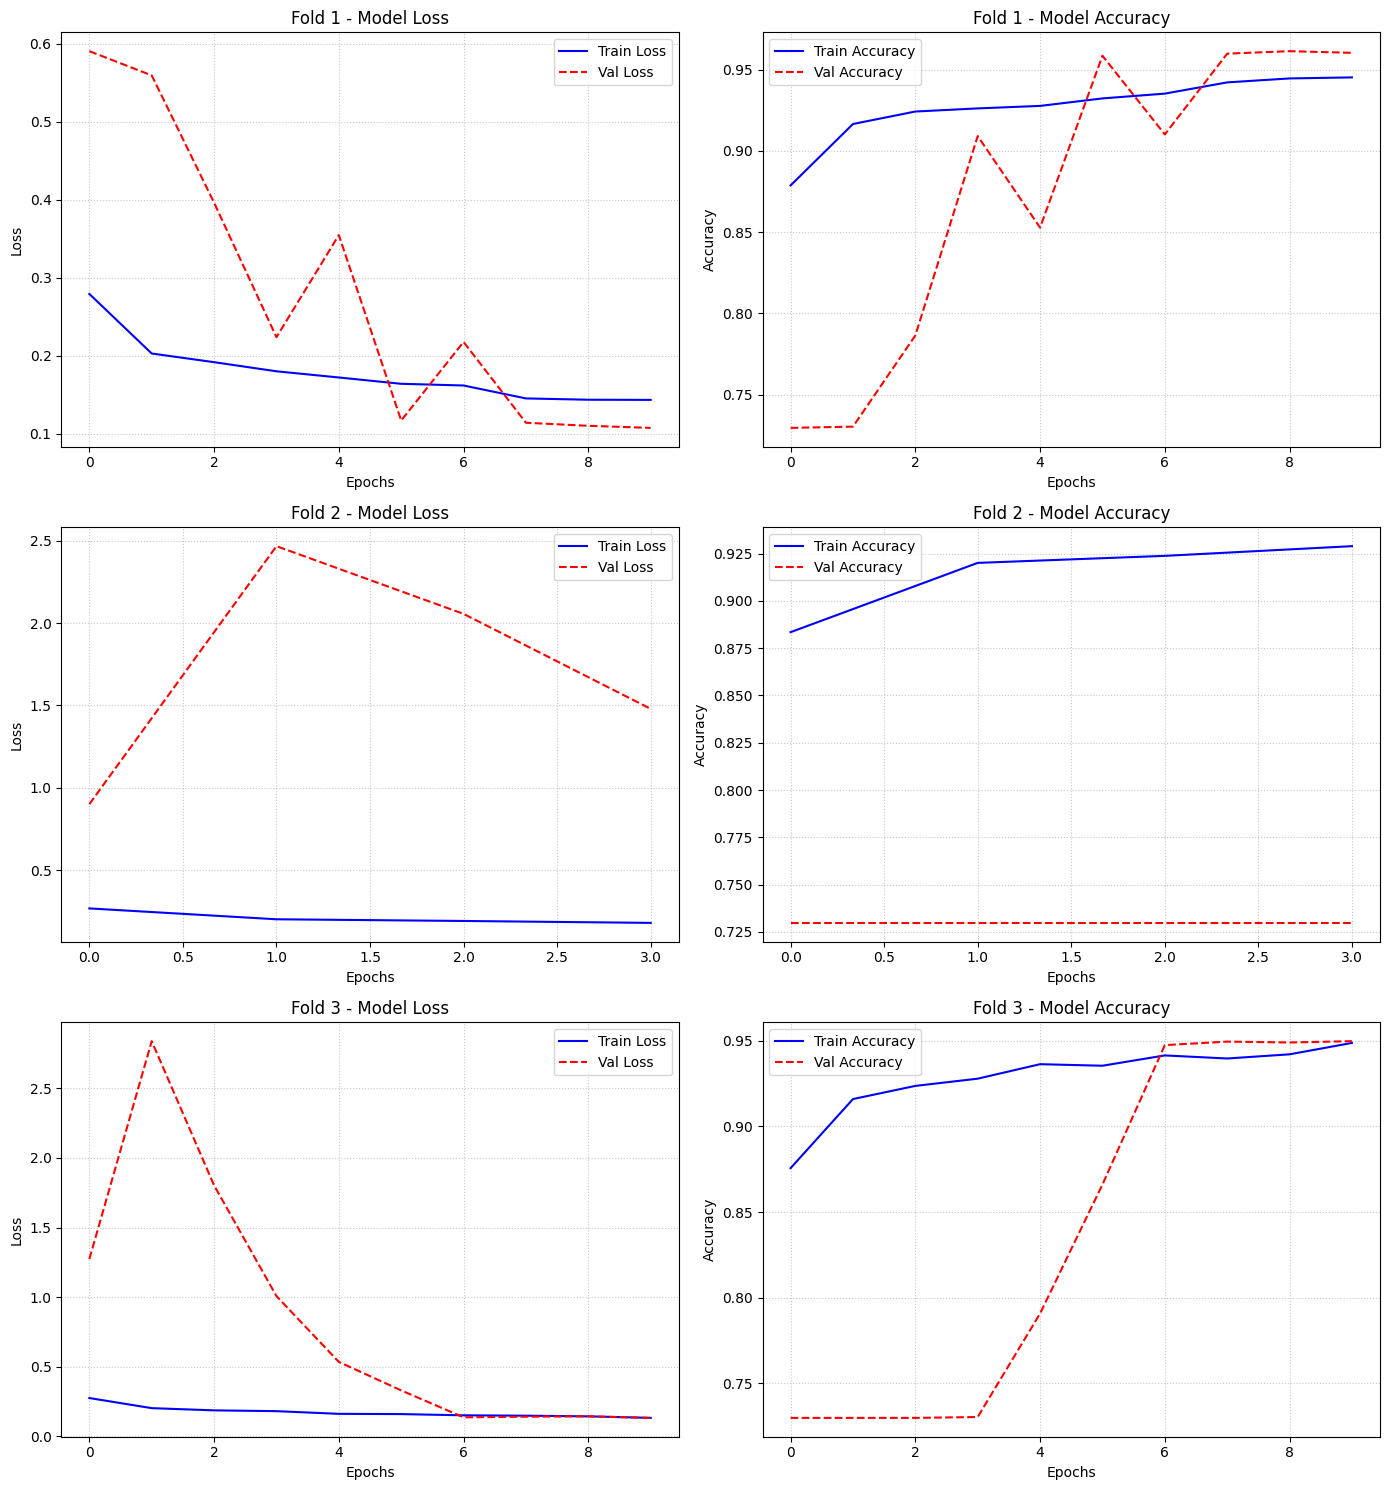

In [ ]:
import matplotlib.pyplot as plt

# This assumes you have modified the training loop to append each history.history to `all_histories`
if 'all_histories' in locals() and len(all_histories) > 0:
    num_folds = len(all_histories)
    fig, axes = plt.subplots(num_folds, 2, figsize=(14, 5 * num_folds))

    # Make sure axes is iterable even if there's only 1 fold
    if num_folds == 1:
        axes = [axes]

    for i, hist in enumerate(all_histories):
        # 1. Loss Plot
        axes[i][0].plot(hist['loss'], label='Train Loss', color='blue')
        axes[i][0].plot(hist['val_loss'], label='Val Loss', color='red', linestyle='--')
        axes[i][0].set_title(f'Fold {i+1} - Model Loss')
        axes[i][0].set_xlabel('Epochs')
        axes[i][0].set_ylabel('Loss')
        axes[i][0].legend()
        axes[i][0].grid(True, linestyle=':', alpha=0.7)

        # 2. Accuracy Plot
        axes[i][1].plot(hist['accuracy'], label='Train Accuracy', color='blue')
        axes[i][1].plot(hist['val_accuracy'], label='Val Accuracy', color='red', linestyle='--')
        axes[i][1].set_title(f'Fold {i+1} - Model Accuracy')
        axes[i][1].set_xlabel('Epochs')
        axes[i][1].set_ylabel('Accuracy')
        axes[i][1].legend()
        axes[i][1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 'all_histories' list not found or is empty.")
    print("To visualize the learning curves, please add `all_histories = []` before your training loop,")
    print("and `all_histories.append(history.history)` at the end of each fold inside the loop.")


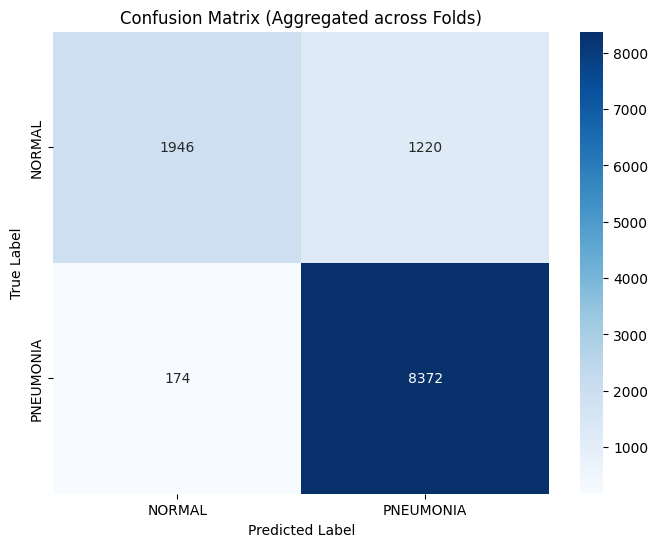


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.61      0.74      3166
   PNEUMONIA       0.87      0.98      0.92      8546

    accuracy                           0.88     11712
   macro avg       0.90      0.80      0.83     11712
weighted avg       0.89      0.88      0.87     11712



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.title('Confusion Matrix (Aggregated across Folds)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=['NORMAL', 'PNEUMONIA']))


Preparing Test Data Generator...
Found 624 images belonging to 2 classes.

Running inferences on test set...
Loading model: /content/drive/MyDrive/resnet50_fold_1.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
Loading model: /content/drive/MyDrive/resnet50_fold_2.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 862ms/step
Loading model: /content/drive/MyDrive/resnet50_fold_3.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 725ms/step

=== Test Set Evaluation (Ensemble vs Individual) ===
Accuracy:  Ensemble=0.8462 | Individual Mean=0.7986 ± 0.1228
Precision: Ensemble=0.8050 | Individual Mean=0.7763 ± 0.1070
Recall:    Ensemble=0.9949 | Individual Mean=0.9923 ± 0.0055
F1 Score:  Ensemble=0.8899 | Individual Mean=0.8665 ± 0.0688
AUC:       Ensemble=0.9722 | Individual Mean=0.9424 ± 0.0416

Classification Report (Ensemble):
              precision    recall  f1-score   support

      NORMAL       0.99      0.60      0.74       234
   PNEUMONIA       0.80      0.99      0.89       390

    accuracy                  

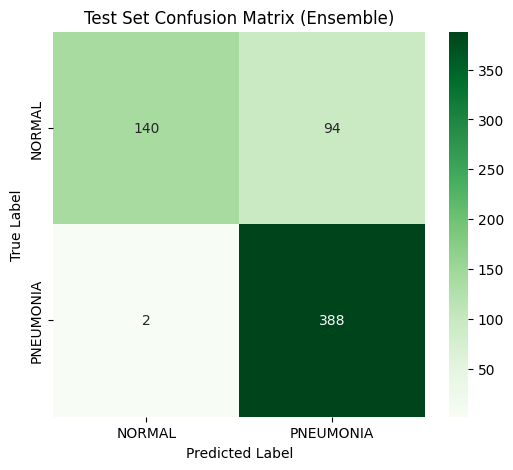

In [ ]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Preparing Test Data Generator...")
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Must be False to match predictions with true labels
)

# Get true labels
test_true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Ensemble predictions from all saved models
all_test_preds = []
test_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}

print("\nRunning inferences on test set...")
for path in saved_model_paths:
    print(f"Loading model: {path}")
    model = tf.keras.models.load_model(path)
    preds = model.predict(test_generator).flatten()
    all_test_preds.append(preds)

    # Evaluate individual model
    pred_labels = (preds > 0.5).astype(int)
    test_metrics['accuracy'].append(accuracy_score(test_true_labels, pred_labels))
    test_metrics['precision'].append(precision_score(test_true_labels, pred_labels))
    test_metrics['recall'].append(recall_score(test_true_labels, pred_labels))
    test_metrics['f1'].append(f1_score(test_true_labels, pred_labels))
    test_metrics['auc'].append(roc_auc_score(test_true_labels, preds))

# Average the probabilities across all folds
avg_test_preds = np.mean(all_test_preds, axis=0)
test_pred_labels = (avg_test_preds > 0.5).astype(int)

# Compute test metrics
print("\n=== Test Set Evaluation (Ensemble vs Individual) ===")

acc_ens = accuracy_score(test_true_labels, test_pred_labels)
acc_mean, acc_std = np.mean(test_metrics['accuracy']), np.std(test_metrics['accuracy'])
print(f"Accuracy:  Ensemble={acc_ens:.4f} | Individual Mean={acc_mean:.4f} ± {acc_std:.4f}")

prec_ens = precision_score(test_true_labels, test_pred_labels)
prec_mean, prec_std = np.mean(test_metrics['precision']), np.std(test_metrics['precision'])
print(f"Precision: Ensemble={prec_ens:.4f} | Individual Mean={prec_mean:.4f} ± {prec_std:.4f}")

rec_ens = recall_score(test_true_labels, test_pred_labels)
rec_mean, rec_std = np.mean(test_metrics['recall']), np.std(test_metrics['recall'])
print(f"Recall:    Ensemble={rec_ens:.4f} | Individual Mean={rec_mean:.4f} ± {rec_std:.4f}")

f1_ens = f1_score(test_true_labels, test_pred_labels)
f1_mean, f1_std = np.mean(test_metrics['f1']), np.std(test_metrics['f1'])
print(f"F1 Score:  Ensemble={f1_ens:.4f} | Individual Mean={f1_mean:.4f} ± {f1_std:.4f}")

auc_ens = roc_auc_score(test_true_labels, avg_test_preds)
auc_mean, auc_std = np.mean(test_metrics['auc']), np.std(test_metrics['auc'])
print(f"AUC:       Ensemble={auc_ens:.4f} | Individual Mean={auc_mean:.4f} ± {auc_std:.4f}")

print("\nClassification Report (Ensemble):")
print(classification_report(test_true_labels, test_pred_labels, target_names=class_names))

# Plot Test Set Confusion Matrix
cm_test = confusion_matrix(test_true_labels, test_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Test Set Confusion Matrix (Ensemble)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


Total misclassified images in test set: 96


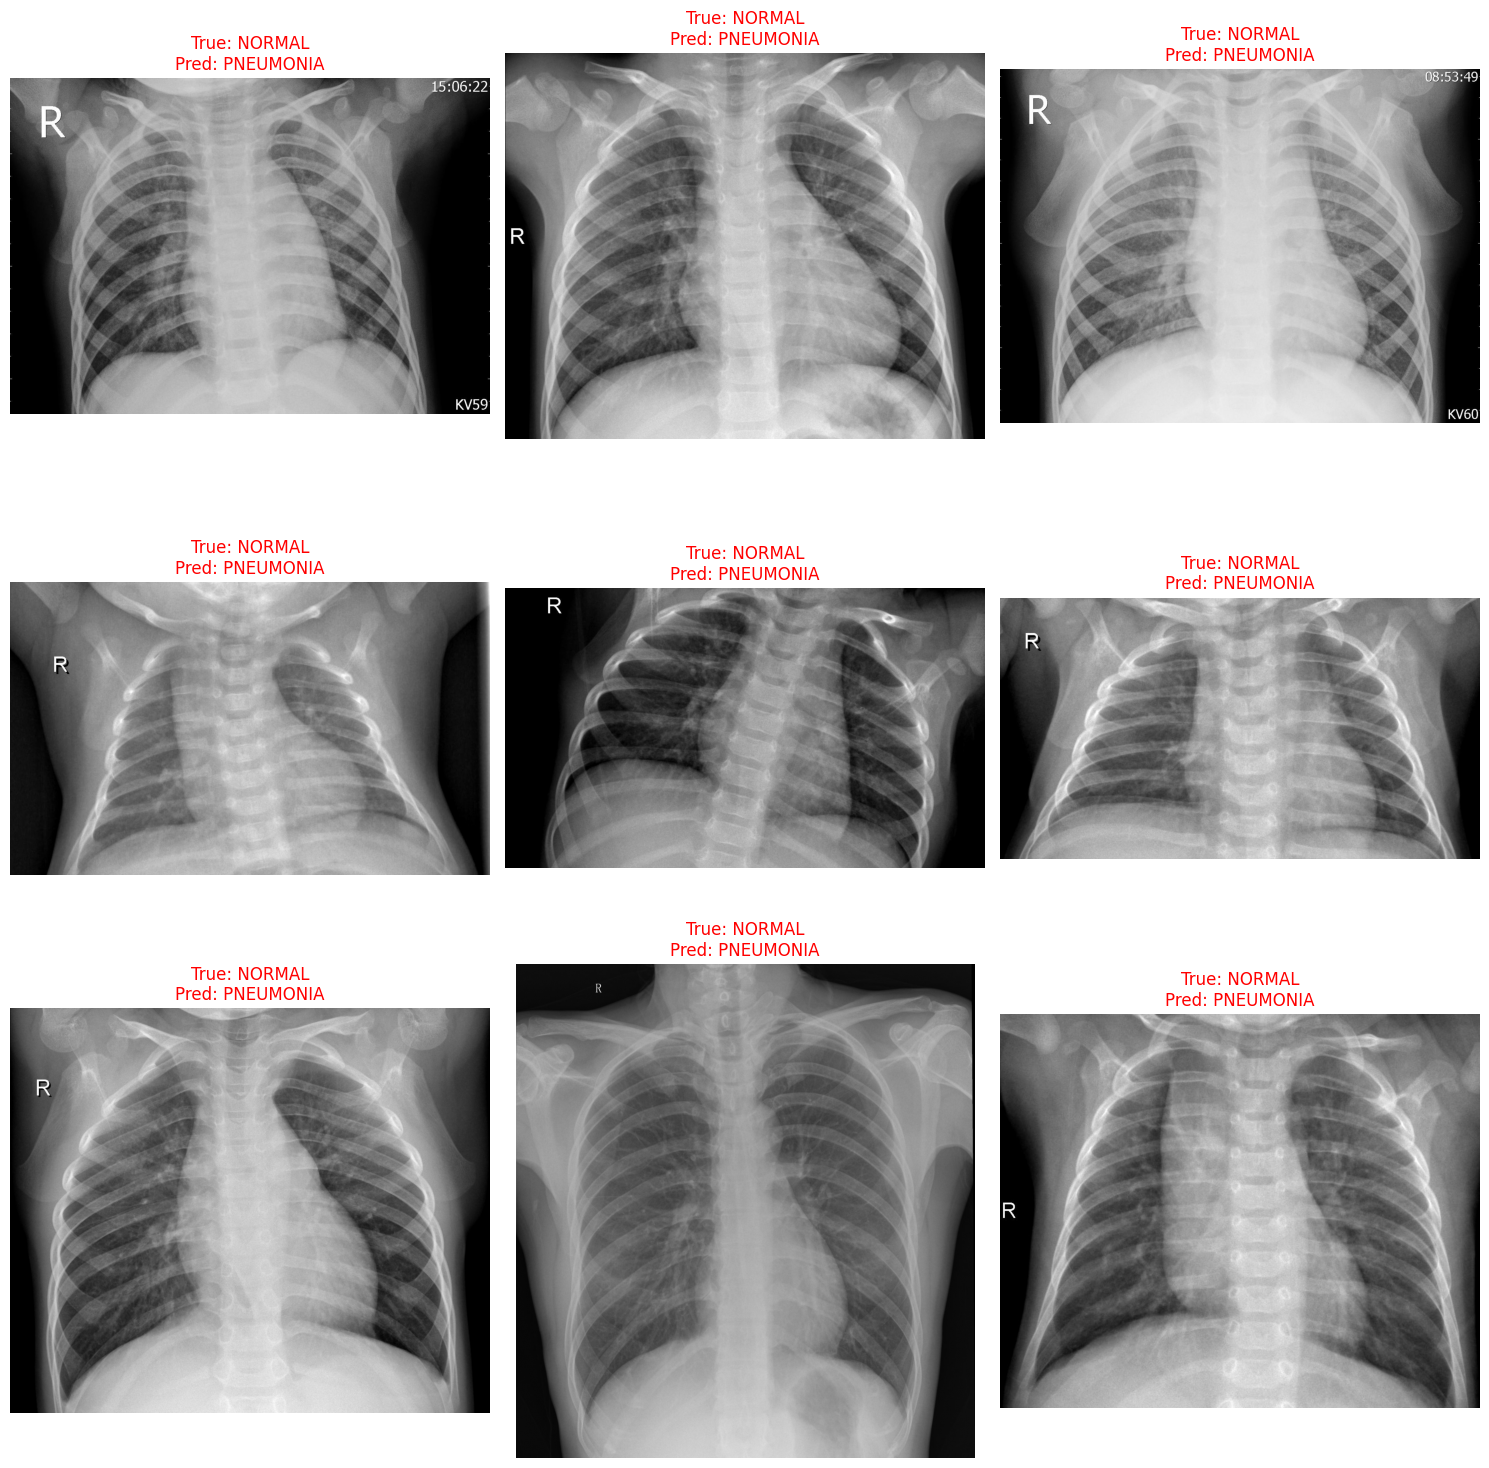

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Find indices where predictions don't match true labels
misclassified_idx = np.where(test_pred_labels != test_true_labels)[0]

if len(misclassified_idx) == 0:
    print("Wow! No misclassifications found on the test set!")
else:
    print(f"Total misclassified images in test set: {len(misclassified_idx)}")

    # Select up to 9 random misclassified images to display
    num_samples = min(9, len(misclassified_idx))
    sample_indices = np.random.choice(misclassified_idx, num_samples, replace=False)

    # Setup plotting grid
    rows = int(np.ceil(num_samples / 3))
    cols = min(3, num_samples)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

    # Ensure axes is a flattened array for easy indexing
    if num_samples == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, idx in enumerate(sample_indices):
        # Get the absolute file path
        img_path = test_generator.filepaths[idx]

        # Map numeric labels back to class names
        true_label = class_names[test_true_labels[idx]]
        pred_label = class_names[test_pred_labels[idx]]

        # Load and show image
        img = mpimg.imread(img_path)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color="red")
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Define paths from previous cells to ensure 'test_dir' is available
extract_dir = '/content/chest_xray_data'
test_dir = os.path.join(extract_dir, 'chest_xray/test')

pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')
if os.path.exists(pneumonia_dir):
    pneumonia_images = [f for f in os.listdir(pneumonia_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    if pneumonia_images:
        sample_pneumonia_path = os.path.join(pneumonia_dir, pneumonia_images[0])
        img = Image.open(sample_pneumonia_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img, cmap='gray')
        plt.title('Sample PNEUMONIA Case')
        plt.axis('off')
        plt.show()
    else:
        print("No PNEUMONIA images found in the test directory.")
else:
    print("PNEUMONIA directory not found in the test set.")

NameError: name 'test_dir' is not defined